<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-burst-prediction/blob/main/MSc_project_data_pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Data and Packages

In [1]:
# import packages required

from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [2]:
# upload files

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# import data

assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding='latin1')
bursts = pd.read_csv("/content/drive/MyDrive/MSc project/burst_data.csv", encoding='latin1')
soil = pd.read_csv("/content/drive/MyDrive/MSc project/soil-pipe-matched.csv", encoding ='latin1')

/tmp/ipykernel_2496/784720674.py:3: DtypeWarning: Columns (22,23,28) have mixed types. Specify dtype option on import or set low_memory=False.
  assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding='latin1')


In [47]:
# import data (if starting the code at section Data Manipulation)

assets_cleaned = pd.read_csv("/content/drive/MyDrive/MSc project/assets_cleaned.csv", encoding = "latin1")
bursts_cleaned = pd.read_csv("/content/drive/MyDrive/MSc project/bursts_cleaned.csv", encoding = "latin1")
soil_cleaned = pd.read_csv("/content/drive/MyDrive/MSc project/soil_cleaned.csv", encoding = "latin1")

# Data Cleaning

### Assets

In [ ]:
# removing assets that are not of interest to the team

assets_cleaned = assets[assets["Type"] == "Distribution"] # only keeping distribution mains

assets_cleaned = assets_cleaned[assets_cleaned["Operational.Status"] != "Abandoned"] # remove abondened assets

assets_cleaned = assets_cleaned[assets_cleaned["Operational.Status"] != "Removed"] # remove removed assets

assets_cleaned = assets_cleaned.drop_duplicates(subset = ["Asset.ID"]) # remove duplicates


In [20]:
# examine % of total length of assets that has missing diamater, age, material or surface code

print(assets_cleaned[pd.isnull(assets_cleaned['ARM_DIAMETER'])]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[pd.isnull(assets_cleaned['ARM_AGE'])]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[assets_cleaned['ARM_MATERIAL'] == "MISSING"]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

print(assets_cleaned[assets_cleaned['ARM_SURFACE_CODE'] == "MISSING"]["ARM_LENGTH"].sum() / assets_cleaned['ARM_LENGTH'].sum() * 100)

KeyError: 'ARM_DIAMETER'

<Axes: xlabel='ARM_AGE', ylabel='Count'>

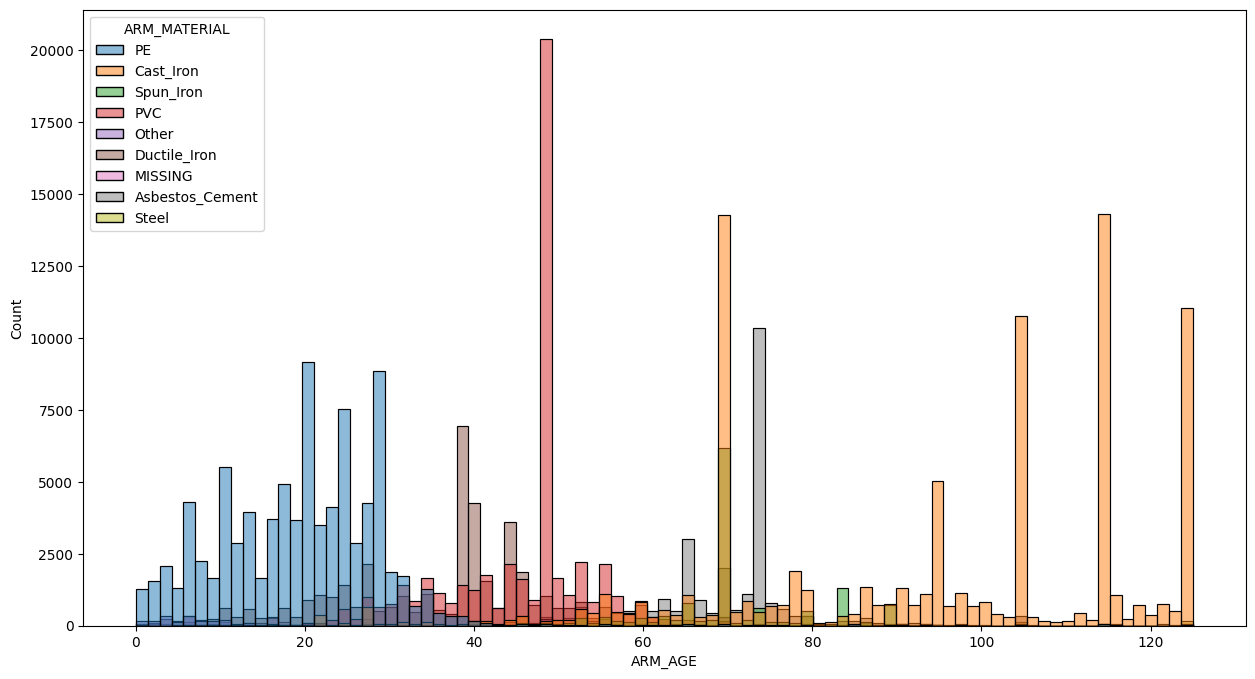

In [ ]:
# examine age profile of assets by material

plt.figure(figsize = [15, 8])
sns.histplot(data = assets_cleaned,
             x = "ARM_AGE",
             hue = "ARM_MATERIAL")

# comment: if an asset it 8 years or younger, then it can be assumed it is made of PE - use for subsitituing material

In [ ]:
# missing values removal

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_DIAMETER"])] # deletes records with missing diameter

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_AGE"])] # deletes records with missing age

assets_cleaned.loc[(assets_cleaned["ARM_MATERIAL"] == "MISSING") & (assets_cleaned["ARM_AGE"] <= 8.0), "ARM_MATERIAL"] = "PE" # imputes assets that have missing material and are 8 or less years with PE

assets_cleaned = assets_cleaned[(assets_cleaned["ARM_MATERIAL"] != "MISSING")] # removes remaining assets with missing material

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "Unknown"] # remove assets with unknown surface code (only 6 has unknown surface)

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "MISSING"] # remove assets with missing surface code (~52k has missing surface) > worth looking at surface, it is used a lot, in city it is a lot more traffic (vibration). on the other hand, in rural areas, there is more temperature difference and land movement. and fittings. > add missing category

assets_cleaned = assets_cleaned[assets_cleaned["ARM_SURFACE_CODE"] != "Unknown"] # remove assets with unknown surface code (only 6 has unknown surface)




In [ ]:
# select columns and re-name columns

assets_cleaned = assets_cleaned[["Asset.ID",
                                 "ARM_MATERIAL",
                                 "ARM_DIAMETER",
                                 "ARM_LENGTH",
                                 "ARM_LINING",
                                 "ARM_SURFACE_CODE",
                                 "ARM_COMMISSIONED"
                                 ]] # selecting attributes

assets_cleaned = assets_cleaned.rename(columns = {"ARM_MATERIAL":"Material",
                                                        "ARM_DIAMETER": "Diameter",
                                                        "ARM_LENGTH": "Length",
                                                        "ARM_LINING": "Lining",
                                                  "ARM_SURFACE_CODE": "Surface",
                                                  "ARM_COMMISSIONED": "Date_comm"}) # renaming columns


In [22]:
# change type

assets_cleaned['Asset.ID'] = assets_cleaned['Asset.ID'].astype(int) # changing asset type from float to integer

assets_cleaned['Date_comm'] = pd.to_datetime(assets_cleaned['Date_comm'], errors = "coerce", dayfirst=True)


In [ ]:
# remove assets that don't have commissioned date in the right format

assets_cleaned = assets_cleaned[~(pd.isnull(assets_cleaned['Date_comm']))]

In [ ]:
# save assets cleaned

assets_cleaned.to_csv("/content/drive/MyDrive/MSc project/assets_cleaned.csv", encoding ='latin1', index=False)

### Bursts

In [ ]:
# bursts cleaning


bursts["Raised.Date"] = pd.to_datetime(bursts["Raised.Date"], dayfirst=True) # transofrms burst date to date format

bursts_cleaned = bursts.drop_duplicates(subset = ["Asset.ID", "Raised.Date"]) # delete duplicate bursts (same day at the same location) - most likely part of the same burst, but reported as two work orders

bursts_cleaned = bursts_cleaned[["Asset.ID", "Raised.Date"]]

bursts_cleaned = bursts_cleaned[pd.notnull(bursts['Asset.ID'])] # removing bursts without asset ID

bursts_cleaned['Asset.ID'] = bursts_cleaned['Asset.ID'].astype(int) # changing Asset ID from float to integer

/tmp/ipykernel_2496/650992958.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bursts_cleaned = bursts_cleaned[pd.notnull(bursts['Asset.ID'])] # removing bursts without asset ID


In [ ]:
# only keep bursts if they occured more than 1 day between each other (if a repeated burst is recorded the day after, it is assumed to come from the same event)

bursts_cleaned = bursts_cleaned.sort_values(["Asset.ID", "Raised.Date"]) # sort bursts by date for each asset

kept_rows = [] # create an empty set to record temaining bursts

for asset_id, bursts in bursts_cleaned.groupby("Asset.ID"): # note: this is a special type of loop that loops through the created groups

    last_date = None

    for _, row in bursts.iterrows():

        current_date = row["Raised.Date"]

        if last_date is None:
            kept_rows.append(row)
            last_date = current_date

        else:
            day_diff = (current_date - last_date).days

            if day_diff > 1:
                kept_rows.append(row)
                last_date = current_date

bursts_cleaned = pd.DataFrame(kept_rows)





In [ ]:
# save bursts cleaned

bursts_cleaned.to_csv("/content/drive/MyDrive/MSc project/bursts_cleaned.csv", encoding ='latin1', index=False)

### Soil

In [ ]:
# soil cleaning

soil_cleaned = soil[["Asset.ID", "Soil"]]

soil_cleaned = soil_cleaned[pd.notnull(soil_cleaned["Soil"])] # removing assets with missing soil

In [ ]:
# save soil cleaned

soil_cleaned.to_csv("/content/drive/MyDrive/MSc project/soil_cleaned.csv", encoding ='latin1', index=False)

# Data manipulation

### Joining

Data on assets, bursts and soil needs to be joined together to form one dataset with attributes for modelling purposes.

In [48]:
# merging assets, bursts and soil together

assets_bursts = pd.merge(assets_cleaned, bursts_cleaned, how = "left", on = "Asset.ID")

assets_bursts_soil = pd.merge(assets_bursts, soil_cleaned, how = "left", on = "Asset.ID")

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil['Soil'])] # removing assets without soil

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil['Raised.Date'])] # removing assets without bursts

Any assets that have censored data (have not had a burst yet) are saved in a separate file to later eveluate how the model performs on censored data.

In [ ]:
# keeep censored data for further analysis

censored_data = assets_bursts_soil[~pd.notnull(assets_bursts_soil["Raised.Date"])] # keeping assets without bursts as censored data

In [50]:
# change data type of the obtained data

assets_bursts_soil["Raised.Date"] = pd.to_datetime(assets_bursts_soil["Raised.Date"], dayfirst=True) # transofrms burst date to date format

assets_bursts_soil['Date_comm'] = pd.to_datetime(assets_bursts_soil["Date_comm"], errors = "coerce")

/tmp/ipykernel_8815/595975331.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  assets_bursts_soil["Raised.Date"] = pd.to_datetime(assets_bursts_soil["Raised.Date"], dayfirst=True) # transofrms burst date to date format


In [ ]:
# save censored data

censored_data.to_csv("/content/drive/MyDrive/MSc project/censored_data.csv", encoding ='latin1', index=False)

### Transformations

A "Time-to-break" column is added as a new attribute to the assets, bursts and soil data set. This column corresponds to the response attribute in models.

In [52]:
# Add "Time-to-break" column

assets_bursts_soil["Time-to-break"] = assets_bursts_soil['Raised.Date'] - assets_bursts_soil['Date_comm']


In [59]:
# Convert "Time-to-break" to an integer

assets_bursts_soil['Time-to-break'] = assets_bursts_soil['Time-to-break'].dt.days

Some assets had a burst recorded before the asset commissioned data, which is likely due to data fill-in error. These assets are removed from the data.

In [63]:
assets_bursts_soil = assets_bursts_soil[assets_bursts_soil['Time-to-break'] >= 0]

A column "Year" is added as an attribute to the data set. The column gives information on the year the asset was comissioned.

In [64]:
assets_bursts_soil["Year"] = assets_bursts_soil['Date_comm'].dt.year

/tmp/ipykernel_8815/1911709944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assets_bursts_soil["Year"] = assets_bursts_soil['Date_comm'].dt.year


A column "Previous bursts" is added as attributes. This column corresponds to the number of previous failures at the time of burst.

In [161]:
# iterrate over asset ID to add previous bursts

bursts_counts_per_asset = pd.DataFrame(assets_bursts_soil['Asset.ID'].value_counts()) # counts the number of bursts for each asset

assets_bursts_soil = assets_bursts_soil.sort_values(["Asset.ID", "Raised.Date"]) # sort bursts by raised fata for each asset

previous_bursts = []

for asset_ID, bursts in assets_bursts_soil.groupby("Asset.ID"): # loops through each asset ID

  bursts_number = int(bursts_counts_per_asset.loc[asset_ID])

  previous_bursts_per_asset = list(range(bursts_number))

  previous_bursts.extend(previous_bursts_per_asset)



/tmp/ipykernel_8815/2427033321.py:7: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  bursts_number = int(bursts_counts_per_asset.loc[asset_ID])


In [162]:
# Add a new column

assets_bursts_soil["Previous bursts"] = previous_bursts

Save the final data set as attributes.

In [165]:
# save data

attributes = assets_bursts_soil

In [166]:
# save attributes

attributes.to_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding ='latin1', index=False)